# **Machine Learning - Assignment - Deep Learning Pipeline**
### *Dataset: [Cat vs. Dog](https://www.kaggle.com/datasets/tongpython/cat-and-dog/versions/1)*

**Course:** Machine Learning | **Supervisor:** TS. Truong Vinh Lan | **Group 7**

| # | Member | Student ID |
|---|--------|------------|
| 1 | Nguyen Manh Quoc Khanh | 2352525 |
| 2 | Phan Ngoc Lan Chi | 2352137 |
| 3 | Ngo Diem Quyen | 2353031 |
| 4 | Tran Lam Anh | 2352067 |
| 5 | Vu Duc Viet Anh | 2352074 |

---

## Overview

This notebook implements the **Deep Learning Pipeline** for binary image classification (Cat vs. Dog),
following the **end-to-end fine-tuning** approach. Shared modules from `modules/` are reused for
EDA, data utilities, and visualisation — keeping both pipelines consistent.

```
0. Configuration
      |
1. EDA  (shared with Classical Pipeline)
   1.1 Data setup
   1.2 Label & spatial distribution
   1.3 Image quality metrics
   1.4 Colour & data quality
      |
2. Preprocessing
   2.1 Data cleaning
   2.2 Spatial outlier removal
   2.3 Stratified train / val / test split
   2.4 Data augmentation preview
      |
3. Model Architecture
   3.1 Pretrained backbone selection
   3.2 Classification head design
   3.3 Model summary
      |
4. Training
   4.1 Dataset & DataLoader
   4.2 Loss, optimizer, scheduler
   4.3 Training loop with early stopping
   4.4 Training curves
      |
5. Evaluation
   5.1 Classification report
   5.2 Confusion matrix
   5.3 Misclassified image gallery
   5.4 Grad-CAM visualisation
      |
6. Comparison with Classical Pipeline
      |
7. Conclusion
```


In [ ]:
!git clone https://github.com/kahn-29/252-MachineLearning-Assignment1.git

Cloning into '252-MachineLearning-Assignment1'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 108 (delta 4), reused 2 (delta 2), pack-reused 89 (from 1)
Receiving objects: 100% (108/108), 85.91 MiB | 32.21 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [ ]:
# import sys
# import os

# repo_path = '/kaggle/working/252-MachineLearning-Assignment1'

# if repo_path not in sys.path:
#     sys.path.append(repo_path)

# %cd $repo_path

---
## 0. Configuration

Edit **only** `USER_CONFIG` to change any experimental setting.
All downstream sections read from the merged `CONFIG` dict.

### 0.1 Environment setup

In [ ]:
import os, sys, subprocess
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    REPO_DIR = Path("/content/252-MachineLearning-Assignment1") # Correct path for the cloned repository
    # No need to clone again as it was done in a previous cell
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    os.chdir(REPO_DIR)
    print("Colab project root:", Path.cwd())
else:
    print("Local environment. Current root:", Path.cwd())

from modules.config_utils import resolve_workspace, ensure_dirs

WORKSPACE  = resolve_workspace(project_name="dl_pipeline")
FEATURE_DIR = WORKSPACE / "features"
FIGURE_DIR  = WORKSPACE / "figures"
MODEL_DIR   = WORKSPACE / "models"
ensure_dirs(FEATURE_DIR, FIGURE_DIR, MODEL_DIR)
print("Workspace:", WORKSPACE)


Colab project root: /content/252-MachineLearning-Assignment1
Workspace: /content/dl_pipeline


### 0.2 Parameter reference

| Group | Key | Default | Description |
|-------|-----|---------|-------------|
| `DATASET` | `kaggle_id` | `tongpython/cat-and-dog` | Kaggle dataset identifier |
| `CLEANING` | `blur_laplacian_min` | `40` | Min Laplacian variance |
| | `min_side_min` | `64` | Min side length in px |
| | `near_mono_ratio_max` | `0.92` | Max near-black+near-white pixel fraction |
| | `aspect_extremity_max` | `5.0` | Max W/H or H/W ratio |
| | `remove_duplicates` | `False` | Enable perceptual-hash near-duplicate removal |
| `SPLIT` | `train/val/test` | `0.8/0.1/0.1` | Dataset split fractions |
| | `seed` | `42` | Random seed for reproducibility |
| `DL` | `backbone` | `efficientnet_b0` | Fine-tuned backbone |
| | `image_size` | `224` | Input resolution |
| | `batch_size` | `32` | Mini-batch size |
| | `epochs` | `20` | Max training epochs |
| | `lr` | `1e-4` | Initial learning rate |
| | `weight_decay` | `1e-4` | AdamW weight decay |
| | `freeze_epochs` | `3` | Epochs with backbone frozen (head warm-up) |
| | `unfreeze_lr` | `1e-5` | LR after backbone is unfrozen |
| | `early_stopping_patience` | `5` | Patience for early stopping |
| | `label_smoothing` | `0.1` | Label smoothing in CrossEntropy |
| | `use_amp` | `True` | Automatic Mixed Precision (CUDA only) |

### 0.3 Backbone options

| Value | Params | Notes |
|-------|--------|-------|
| `"resnet18"` | 11 M | Lightweight; great baseline |
| `"resnet50"` | 25 M | Deeper ResNet; stronger features |
| `"vgg16"` | 138 M | Memory-intensive; sequential |
| `"efficientnet_b0"` | 5.3 M | Best accuracy/speed; **recommended** |
| `"efficientnet_b2"` | 7.7 M | Slightly larger EfficientNet variant |


In [ ]:
from modules.config_utils import deep_update, set_seed, get_device, ensure_dirs, resolve_workspace

DEFAULT_CONFIG = {
    "DATASET": {
        "kaggle_id": "tongpython/cat-and-dog",
    },
    "CLEANING": {
        "blur_laplacian_min":   40.0,
        "min_side_min":         64,
        "near_mono_ratio_max":  0.92,
        "aspect_extremity_max": 5.0,
        "remove_corrupted":     True,
        "remove_duplicates":    False,
    },
    "SPLIT": {
        "train": 0.8,
        "val":   0.1,
        "test":  0.1,
        "seed":  42,
    },
    "DL": {
        # Backbone: "resnet18" | "resnet50" | "vgg16" | "efficientnet_b0" | "efficientnet_b2"
        "backbone":               "efficientnet_b0",
        "image_size":             224,
        "batch_size":             32,
        "epochs":                 20,
        "lr":                     1e-4,
        "weight_decay":           1e-4,
        "freeze_epochs":          3,      # warm-up: freeze backbone, train head only
        "unfreeze_lr":            1e-5,   # LR after unfreezing backbone
        "early_stopping_patience": 5,
        "label_smoothing":        0.1,
        "use_amp":                True,   # Automatic Mixed Precision (CUDA only)
        "num_workers":            2,
        "dropout_head":           0.3,    # dropout before final FC
    },
}

# IMPORTANT: Edit only this block
USER_CONFIG = {
    # Examples:
    # "DL": {"backbone": "resnet50", "epochs": 30},
    # "DL": {"freeze_epochs": 0, "lr": 5e-5},
}

CONFIG = deep_update(DEFAULT_CONFIG, USER_CONFIG)
SEED   = CONFIG["SPLIT"]["seed"]
DEVICE = get_device()
set_seed(SEED)

print("Active configuration:")
print(f"  Backbone               : {CONFIG['DL']['backbone']}")
print(f"  Image size             : {CONFIG['DL']['image_size']}")
print(f"  Batch size             : {CONFIG['DL']['batch_size']}")
print(f"  Epochs                 : {CONFIG['DL']['epochs']}")
print(f"  Freeze epochs (warm-up): {CONFIG['DL']['freeze_epochs']}")
print(f"  Device                 : {DEVICE}")


Active configuration:
  Backbone               : efficientnet_b0
  Image size             : 224
  Batch size             : 32
  Epochs                 : 20
  Freeze epochs (warm-up): 3
  Device                 : cuda


---
## 1. Exploratory Data Analysis (EDA)

*EDA is identical to the Classical Pipeline - shared `modules/` functions are reused.*

| Sub-section | Content |
|-------------|----------|
| 1.1 Data setup | Download, build registry, run full image audit |
| 1.2 Label & spatial distribution | Class balance, size scatter, aspect ratio |
| 1.3 Image quality metrics | Blur, entropy, saturation, saliency distributions |
| 1.4 Colour & data quality | RGB KDE per class, missing value audit |
| 1.5 EDA summary | Key findings mapped to preprocessing decisions |

### 1.1 Data Setup
#### 1.1.1 Download dataset & build registry

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from modules.data_utils import resolve_dataset_root, build_raw_dataframe

dataset_root = resolve_dataset_root(dataset_id=CONFIG["DATASET"]["kaggle_id"])
print("Dataset root:", dataset_root)

raw_df = build_raw_dataframe(dataset_root)
print(f"Registry: {len(raw_df):,} images")
print(f"Classes : {raw_df['label_name'].value_counts().to_dict()}")
display(raw_df.head(4))


Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset root: /kaggle/input/cat-and-dog
Registry: 10,028 images
Classes : {'dog': 5017, 'cat': 5011}


,sample_id,path,label,label_name,filename,extension
0,0,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4001.jpg,.jpg
1,1,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4002.jpg,.jpg
2,2,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4003.jpg,.jpg
3,3,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,cat.4004.jpg,.jpg


#### 1.1.2 Full image audit (quality metrics per image)

In [ ]:
from tqdm.auto import tqdm
from modules.image_audit import audit_dataframe, describe_audit_metrics

print("Running image audit (this may take a few minutes)...")
audit_df = audit_dataframe(raw_df, compute_hash=CONFIG["CLEANING"]["remove_duplicates"])

print(f"Audit complete: {len(audit_df):,} images")
print(f"Corrupted     : {audit_df['is_corrupted'].sum()}")
display(audit_df.head(3))


Running image audit (this may take a few minutes)...


Auditing images:   0%|          | 0/10028 [00:00<?, ?it/s]

Audit complete: 10,028 images
Corrupted     : 0


,path,label,label_name,is_corrupted,width,height,min_side,max_side,aspect_ratio,aspect_extremity,...,mean_sat,std_sat,chroma_mean,chroma_std,chromaticity_spread,center_saliency_ratio,saliency_mean,saliency_max,compression_artifact,phash
0,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,False,498,415,415,498,1.200000,1.200000,...,52.551033,40.458553,29.447409,24.467079,0.049025,0.209816,87.928177,770.778809,1.089547,None
1,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,False,375,499,375,499,0.751503,1.330667,...,155.615341,65.848640,62.997375,35.315998,0.067559,0.338814,56.109222,452.249939,1.367391,None
2,/kaggle/input/cat-and-dog/test_set/test_set/ca...,0,cat,False,500,399,399,500,1.253133,1.253133,...,83.126656,37.684052,40.666061,24.284052,0.035029,0.272096,54.564804,504.961395,1.383362,None


<!-- #### 1.1.3 Audit metric statistics -->

In [ ]:
# stats = describe_audit_metrics(audit_df)
# print("Descriptive statistics for key quality metrics:")
# display(stats.round(3))


### 1.2 Label & Spatial Distribution
#### 1.2.1 Class balance

,label_name,count,percentage
0,cat,5011,49.97
1,dog,5017,50.03


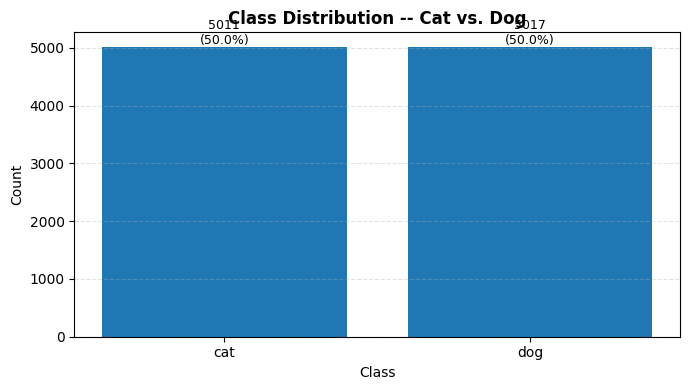

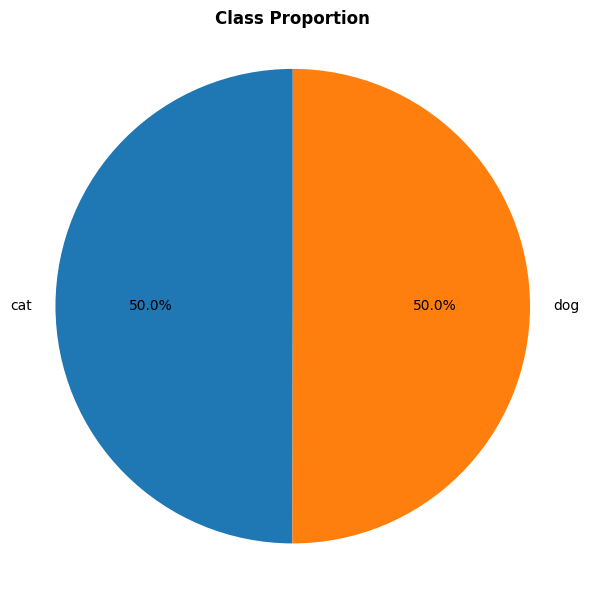

In [ ]:
from modules.visualization import plot_bar_chart, plot_pie_chart

plot_bar_chart(
    raw_df, category_col="label_name", title="Class Distribution -- Cat vs. Dog",
    save_path=FIGURE_DIR / "dl_01_class_bar.png"
)
plot_pie_chart(
    raw_df, category_col="label_name", title="Class Proportion",
    save_path=FIGURE_DIR / "dl_02_class_pie.png"
)

from modules.data_utils import summarize_class_distribution
display(summarize_class_distribution(raw_df))


#### 1.2.2 Image size scatter & aspect ratio

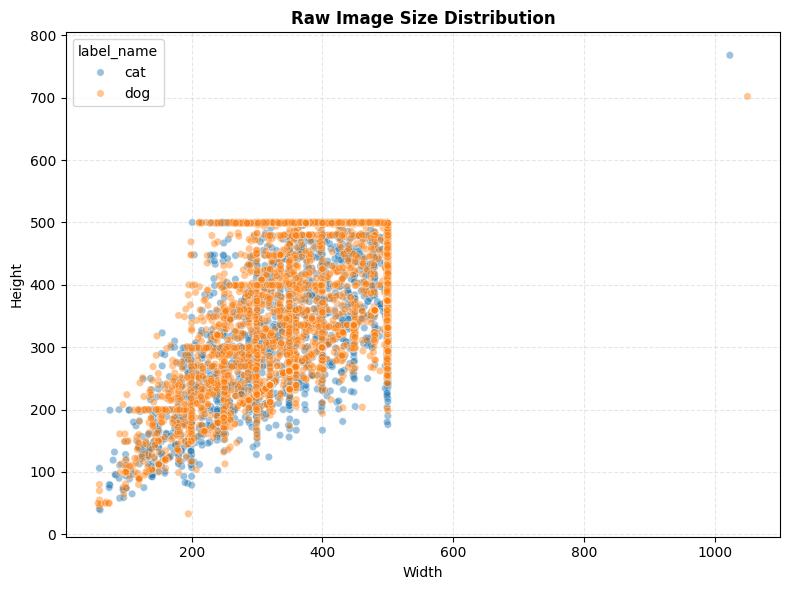

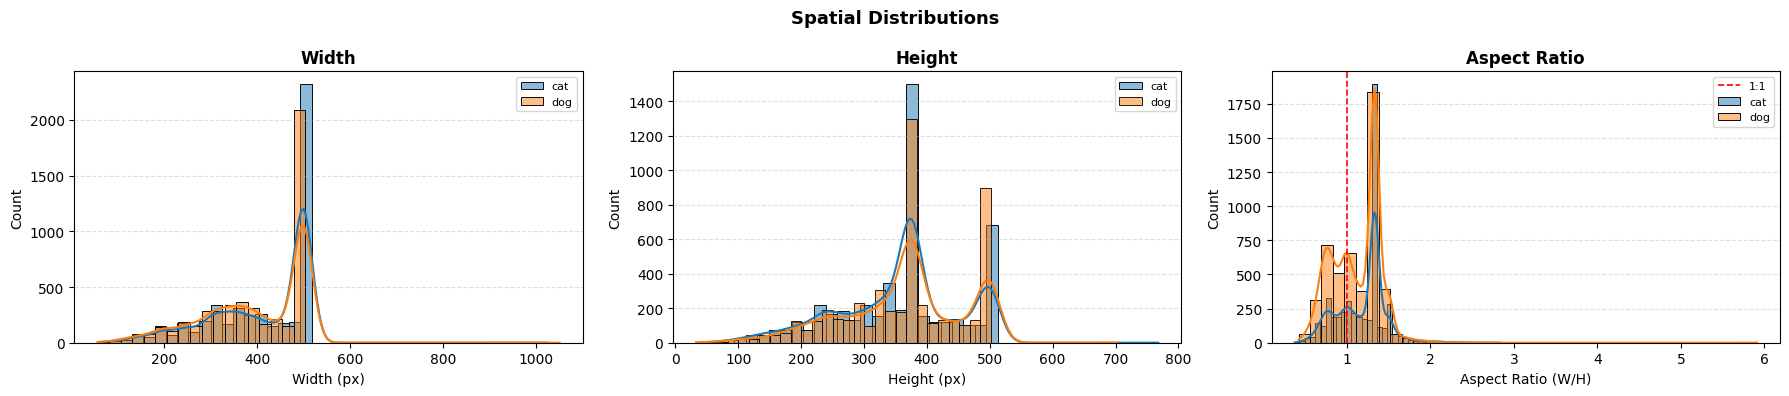

In [ ]:
from modules.visualization import plot_scatter_distribution

plot_scatter_distribution(
    audit_df,
    x_col="width",
    y_col="height",
    hue_col="label_name",
    title="Raw Image Size Distribution",
    save_path=FIGURE_DIR / "dl_03_size_scatter.png"
)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Spatial Distributions", fontsize=13, fontweight="bold")

for ax, (col, xlabel) in zip(axes, [
    ("width", "Width (px)"), ("height", "Height (px)"), ("aspect_ratio", "Aspect Ratio (W/H)")
]):
    for lbl in audit_df["label_name"].dropna().unique():
        sns.histplot(audit_df[audit_df["label_name"]==lbl][col].dropna(),
                     bins=40, kde=True, label=lbl, alpha=0.5, ax=ax)
    if col == "aspect_ratio":
        ax.axvline(1.0, color="red", linestyle="--", lw=1.2, label="1:1")
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(xlabel); ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()


#### 1.2.3 Sample image gallery

(<Figure size 1200x480 with 10 Axes>,
 array([[<Axes: ylabel='cat'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='dog'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >]],
       dtype=object))

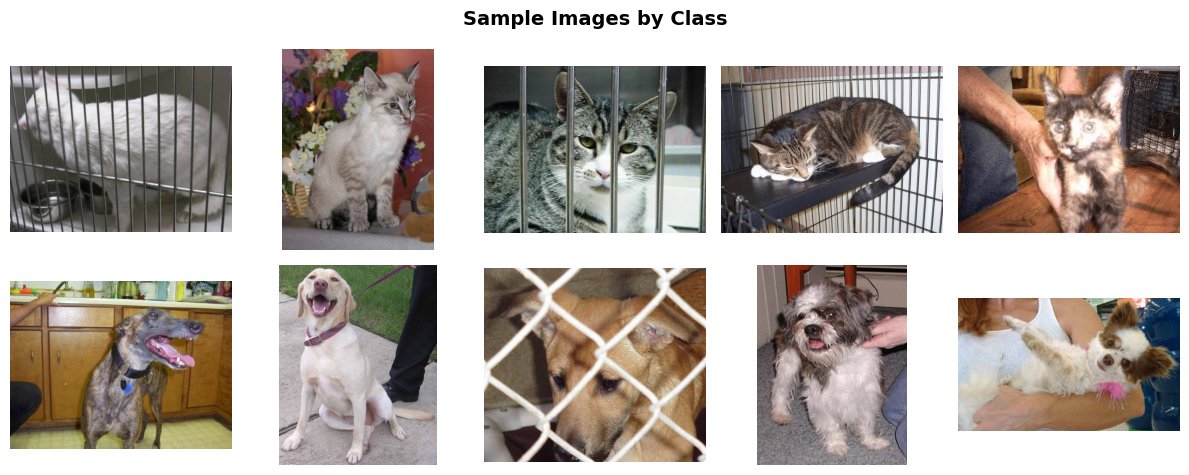

In [ ]:
from modules.visualization import plot_sample_grid

plot_sample_grid(
    raw_df, n_per_class=5, path_col="path", label_col="label_name",
    seed=SEED, save_path=FIGURE_DIR / "dl_04_sample_grid.png"
)


### 1.3 Image Quality Metrics

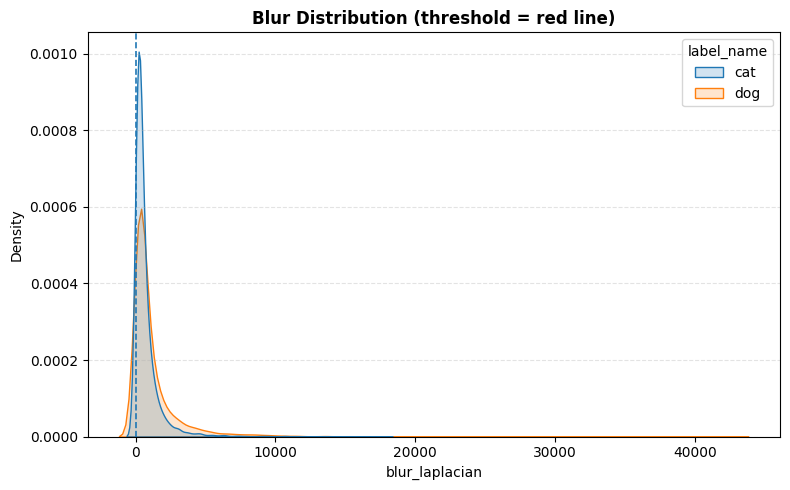

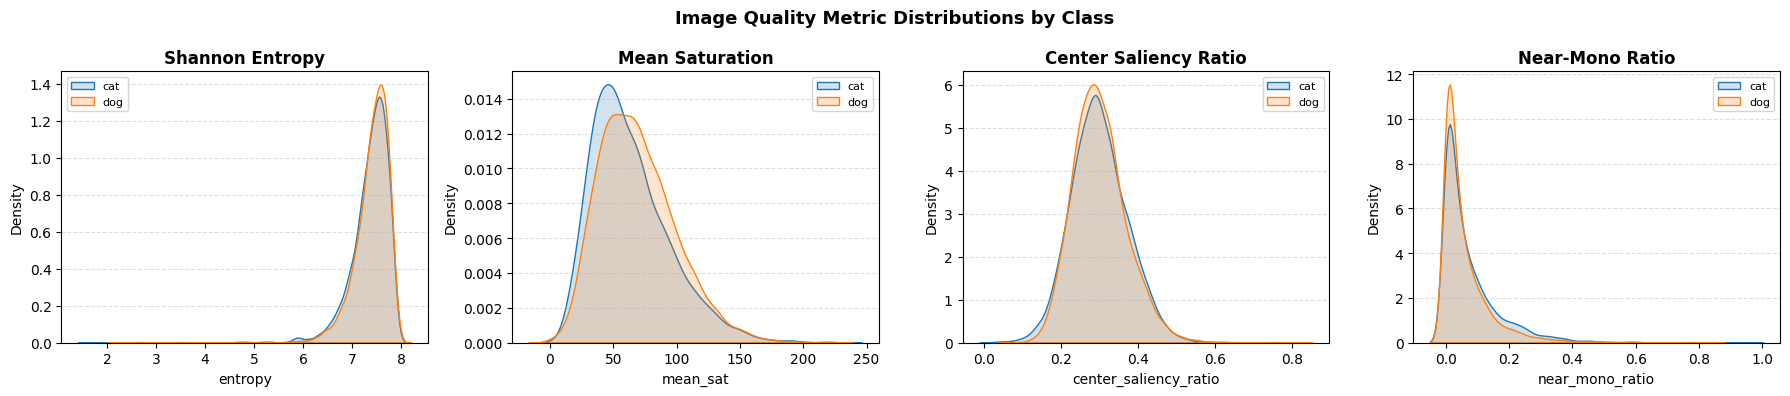

In [ ]:
from modules.visualization import plot_metric_distribution

plot_metric_distribution(
    audit_df, metric="blur_laplacian", label_col="label_name",
    thresholds=[CONFIG["CLEANING"]["blur_laplacian_min"]],
    title="Blur Distribution (threshold = red line)",
    save_path=FIGURE_DIR / "dl_05_blur_dist.png"
)

metrics_to_plot = [
    ("entropy",               "Shannon Entropy"),
    ("mean_sat",              "Mean Saturation"),
    ("center_saliency_ratio", "Center Saliency Ratio"),
    ("near_mono_ratio",       "Near-Mono Ratio"),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))
fig.suptitle("Image Quality Metric Distributions by Class", fontsize=13, fontweight="bold")

for ax, (metric, title) in zip(axes, metrics_to_plot):
    if metric not in audit_df.columns:
        ax.axis("off"); continue
    for lbl in audit_df["label_name"].dropna().unique():
        sub = audit_df[audit_df["label_name"]==lbl][metric].dropna()
        sns.kdeplot(sub, label=lbl, fill=True, alpha=0.2, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(metric); ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout(); plt.show()


### 1.4 Colour & Data Quality
#### 1.4.1 RGB channel KDE by class

(<Figure size 1200x450 with 2 Axes>,
 array([<Axes: title={'center': 'cat'}, xlabel='Mean Intensity', ylabel='Density'>,
        <Axes: title={'center': 'dog'}, xlabel='Mean Intensity', ylabel='Density'>],
       dtype=object))

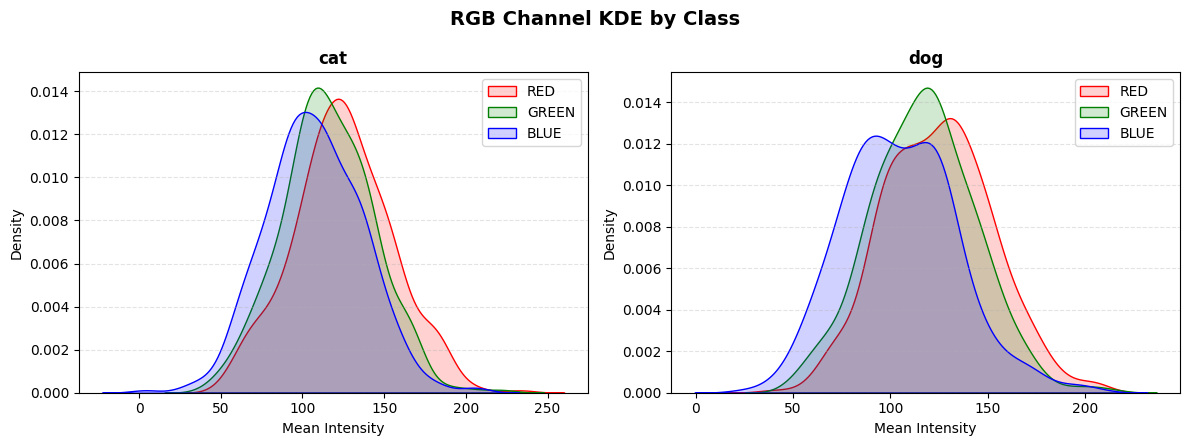

In [ ]:
from modules.visualization import plot_rgb_channel_kde

plot_rgb_channel_kde(
    raw_df, sample_per_class=400, path_col="path", label_col="label_name",
    seed=SEED, save_path=FIGURE_DIR / "dl_06_rgb_kde.png"
)


#### 1.4.2 Missing value audit

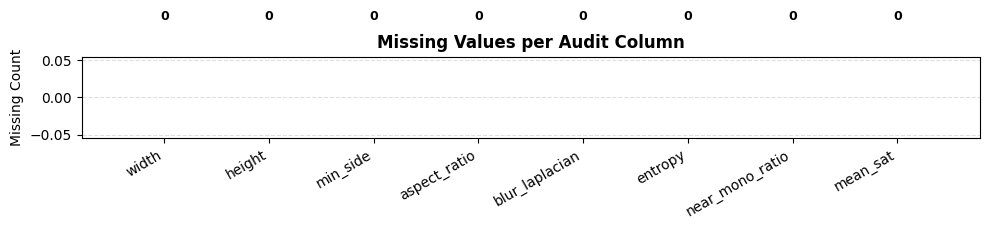

[OK] No missing values.


In [ ]:
meta_cols = ["width", "height", "min_side", "aspect_ratio",
             "blur_laplacian", "entropy", "near_mono_ratio", "mean_sat"]
missing = audit_df[meta_cols].isnull().sum()

fig, ax = plt.subplots(figsize=(10, 3))
bar_colors = ["#d62728" if v > 0 else "#2ca02c" for v in missing.values]
ax.bar(missing.index, missing.values, color=bar_colors)
ax.set_title("Missing Values per Audit Column", fontweight="bold")
ax.set_ylabel("Missing Count"); ax.set_xlabel("")
for i, v in enumerate(missing.values):
    ax.text(i, v + 0.1, str(v), ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

print("[OK] No missing values." if missing.sum() == 0 else f"[WARNING] {missing.sum()} missing values.")


### 1.5 EDA Summary

| # | Finding | Evidence | DL Pipeline Decision |
|---|---------|----------|----------------------|
| 1 | Balanced classes | ~50% cat / ~50% dog | No class weighting required |
| 2 | High resolution variability | Width std ~108 px | Resize to 224×224 with letterbox |
| 3 | Blur is dominant quality issue | Laplacian var < 40 for ~2-3% | Apply blur threshold filter |
| 4 | No colour discriminability | R/G/B KDE overlaps | Model relies on shape/texture |
| 5 | Near-zero missing values | 0 nulls in metadata | No imputation needed |


---
## 2. Preprocessing

| Step | Module | Description |
|------|--------|-------------|
| 2.1 | `cleaning` | Quality filtering -- blur, size, monochrome, (near-duplicate) |
| 2.2 | `cleaning` | Spatial outlier removal (3-sigma) |
| 2.3 | `data_utils` | Stratified 80/10/10 train/val/test split |
| 2.4 | `transforms` | Data augmentation preview |

### 2.1 Data Cleaning

In [ ]:
from modules.cleaning import (
    apply_cleaning, summarize_cleaning,
    summarize_removal_reasons, evaluate_cleaning_retention
)

clean_df, removed_df = apply_cleaning(audit_df, CONFIG["CLEANING"])

retention = evaluate_cleaning_retention(raw_df, clean_df)

print(f"Before cleaning : {retention['n_before']:,}")
print(f"After  cleaning : {retention['n_after']:,}")
print(f"Removed         : {retention['n_removed']:,}  ({retention['removal_rate']*100:.2f}%)")
print(f"Class balance shift: {retention['class_balance_shift']:.4f}")

summary_clean = summarize_cleaning(raw_df, clean_df, removed_df)
display(summary_clean)

reasons = summarize_removal_reasons(removed_df)
print("\nRemoval reasons:")
display(reasons)


Before cleaning : 10,028
After  cleaning : 10,028
Removed         : 0  (0.00%)
Class balance shift: 0.0000


,label_name,count_before,count_after,count_removed,pct_before,pct_after,removal_rate_pct
0,cat,5011,5011,0,49.97,49.97,0.0
1,dog,5017,5017,0,50.03,50.03,0.0
2,TOTAL,10028,10028,0,100.00,100.00,0.0



Removal reasons:


,removal_reason,count,percentage


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Class Counts Before and After Cleaning'}, xlabel='Class', ylabel='Count'>)

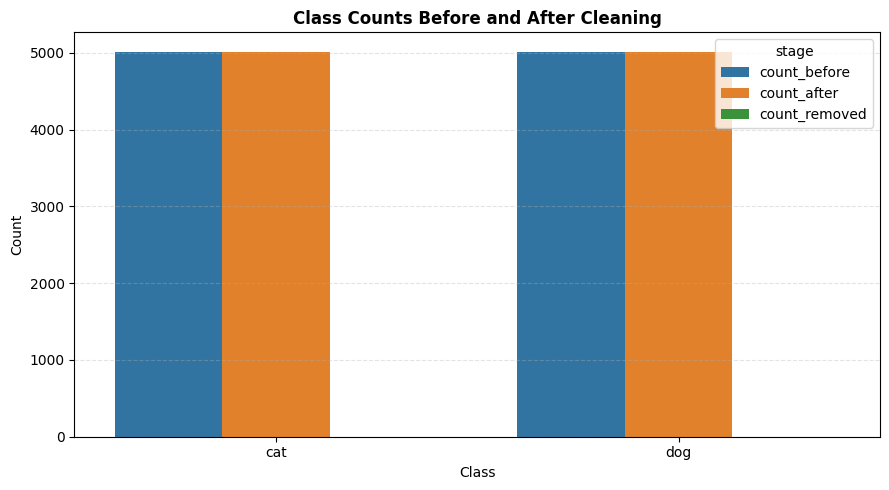

In [ ]:
from modules.visualization import plot_before_after_cleaning

plot_before_after_cleaning(
    summary_clean,
    save_path=FIGURE_DIR / "dl_07_before_after_cleaning.png"
)


### 2.2 Spatial Outlier Removal

In [ ]:
n_before = len(clean_df)

for col in ["width", "height"]:
    mu, sd = clean_df[col].mean(), clean_df[col].std()
    lo, hi = mu - 3*sd, mu + 3*sd
    clean_df = clean_df[(clean_df[col] >= lo) & (clean_df[col] <= hi)]

clean_df = clean_df.reset_index(drop=True)
print(f"After spatial outlier removal: {len(clean_df):,} images  (removed {n_before - len(clean_df)})")


After spatial outlier removal: 10,002 images  (removed 26)


### 2.3 Stratified Train / Validation / Test Split

In [ ]:
from modules.data_utils import stratified_split, summarize_split_distribution

train_df, val_df, test_df = stratified_split(
    clean_df,
    train_ratio = CONFIG["SPLIT"]["train"],
    val_ratio   = CONFIG["SPLIT"]["val"],
    test_ratio  = CONFIG["SPLIT"]["test"],
    seed        = SEED,
)

split_summary = summarize_split_distribution(train_df, val_df, test_df)
display(split_summary)


,split,split_size,label_name,count,percentage
0,train,8001,cat,3998,49.97
1,train,8001,dog,4003,50.03
2,val,1000,cat,500,50.00
3,val,1000,dog,500,50.00
4,test,1001,cat,500,49.95
5,test,1001,dog,501,50.05


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Class Distribution Across Splits'}, xlabel='Split', ylabel='Count'>)

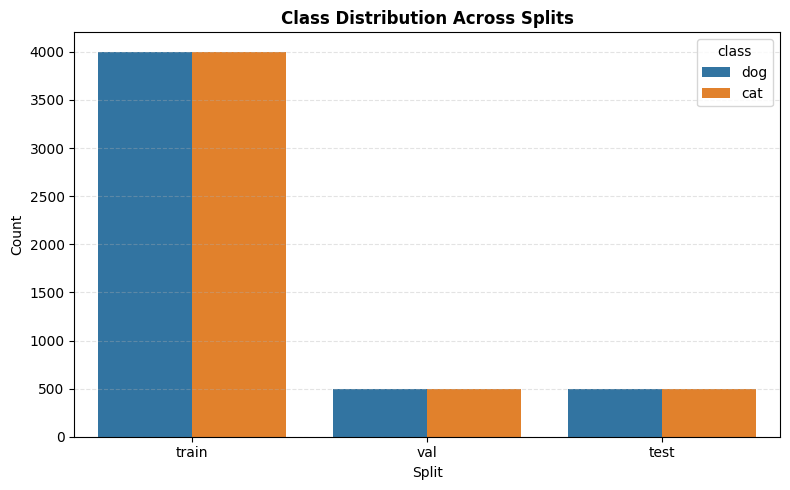

In [ ]:
from modules.visualization import plot_split_distribution
print(type(train_df))
print(type(val_df))
print(type(test_df))
plot_split_distribution(
    splits={
        "train": train_df,
        "val": val_df,
        "test": test_df
    },
    label_col="label_name",
    save_path=FIGURE_DIR / "dl_08_split_distribution.png"
)


### 2.4 Data Augmentation

The **Deep Learning pipeline** uses stronger augmentation during training compared to
the Classical pipeline. This reduces overfitting and improves generalisation.

| Stage | Transform | Rationale |
|-------|-----------|-----------|
| Training | RandomHorizontalFlip | Cats/dogs appear in both orientations |
| Training | RandomRotation(±15°) | Slight pose variation |
| Training | ColorJitter | Lighting variation robustness |
| Training | RandomResizedCrop | Scale/crop invariance |
| Train+Eval | Normalize(ImageNet) | Match pretrained backbone statistics |
| Eval | CenterCrop | Deterministic crop for fair evaluation |


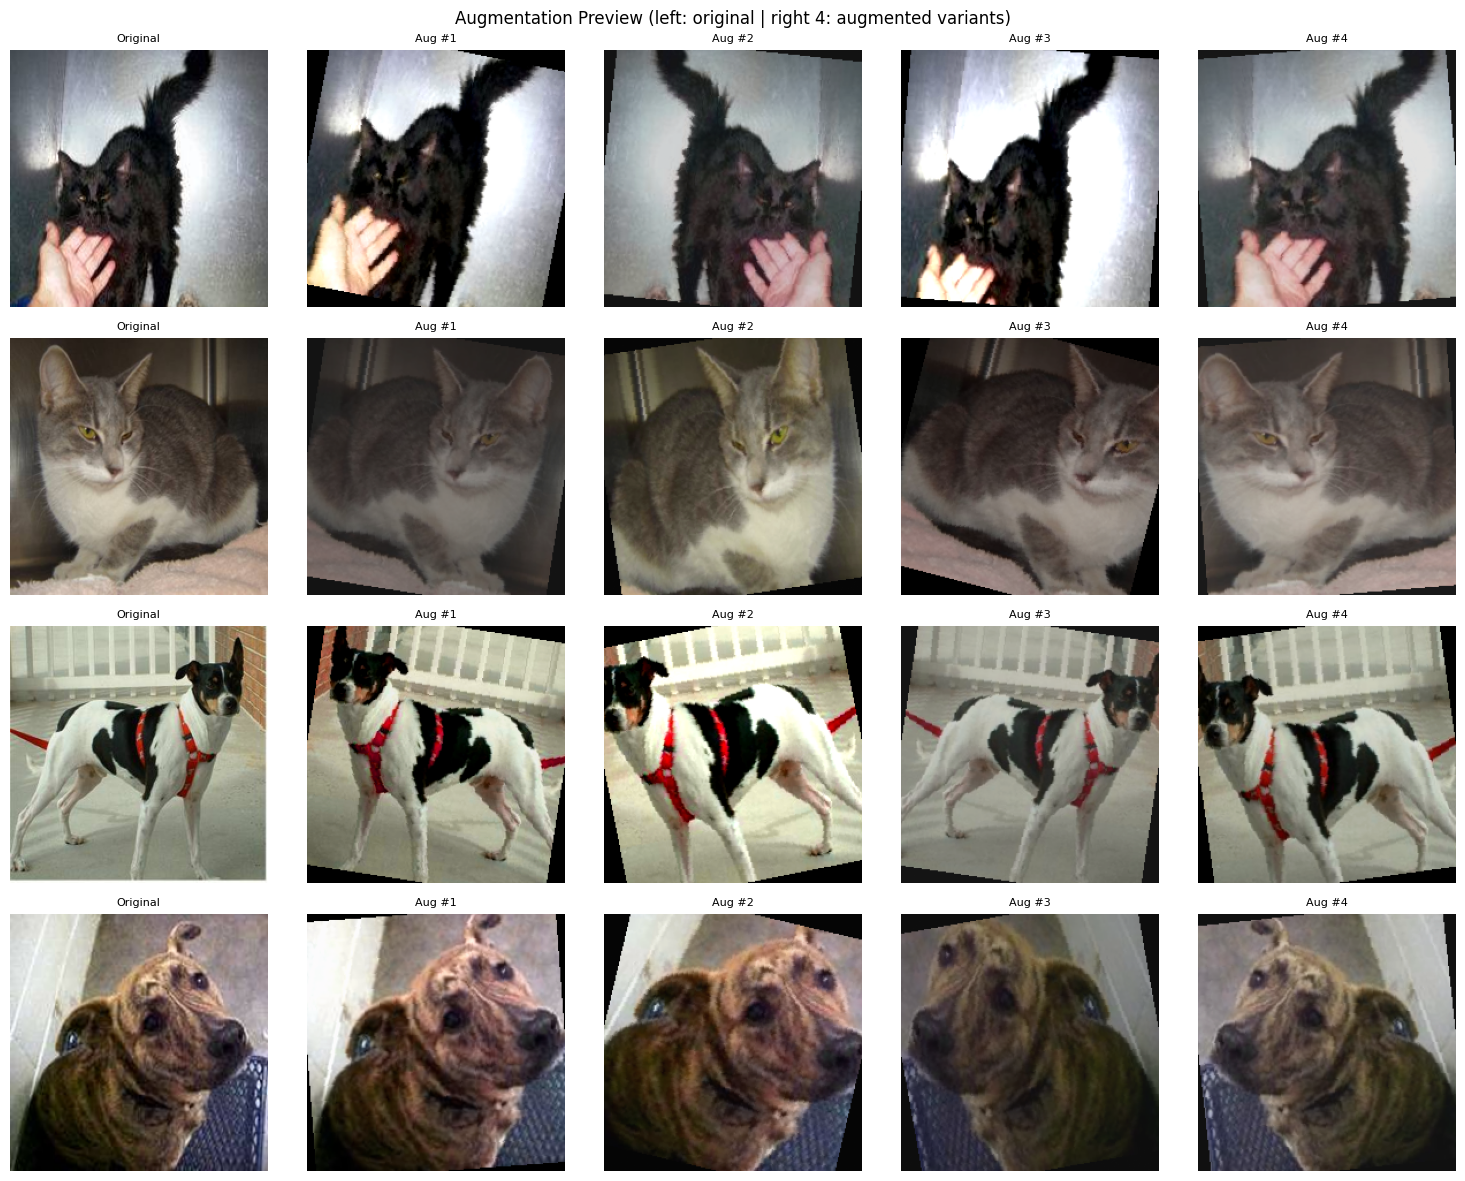

Augmentation preview saved.


In [ ]:
import torchvision.transforms as T
from modules.transforms import tensor_to_display_image
from modules.data_utils import sample_by_class
from PIL import Image

DL_CFG   = CONFIG["DL"]
IMG_SIZE = DL_CFG["image_size"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Preview augmentations
sample_paths = sample_by_class(train_df, n_per_class=2, seed=SEED)["path"].tolist()

fig, axes = plt.subplots(len(sample_paths), 5, figsize=(15, 3 * len(sample_paths)))
fig.suptitle("Augmentation Preview (left: original | right 4: augmented variants)", fontsize=12)

for row, path in enumerate(sample_paths):
    orig = Image.open(path).convert("RGB")
    axes[row, 0].imshow(orig.resize((IMG_SIZE, IMG_SIZE)))
    axes[row, 0].set_title("Original", fontsize=8)
    axes[row, 0].axis("off")
    for col in range(1, 5):
        aug = tensor_to_display_image(train_transform(orig), denormalize=True)
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f"Aug #{col}", fontsize=8)
        axes[row, col].axis("off")

plt.tight_layout(); plt.savefig(FIGURE_DIR / "dl_09_augmentation_preview.png", dpi=120); plt.show()
print("Augmentation preview saved.")


---
## 3. Model Architecture

The fine-tuning strategy follows a **two-phase** approach:

1. **Phase 1 - Head warm-up** (`freeze_epochs` epochs): backbone weights are frozen;
   only the classification head is trained. This avoids destroying pretrained features
   in the early iterations.

2. **Phase 2 - Full fine-tuning** (remaining epochs): all layers are unfrozen and
   trained with a smaller learning rate (`unfreeze_lr`). The backbone adapts to the
   Cat vs. Dog distribution while retaining ImageNet knowledge.

```
Backbone (pretrained on ImageNet)
    └── Global Average Pooling
          └── Dropout (0.3)
                └── Linear(feature_dim -> 2)
                      └── Softmax
```

### 3.1 Build the model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

def build_dl_model(backbone_name: str, num_classes: int = 2, dropout: float = 0.3) -> nn.Module:
    """Return a pretrained backbone with a fresh classification head."""
    backbone_name = backbone_name.lower()

    if backbone_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif backbone_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif backbone_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif backbone_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    elif backbone_name == "efficientnet_b2":
        model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    return model


def freeze_backbone(model: nn.Module, backbone_name: str) -> None:
    """Freeze all layers except the classification head."""
    head_names = {"resnet18": "fc", "resnet50": "fc",
                  "vgg16": "classifier", "efficientnet_b0": "classifier",
                  "efficientnet_b2": "classifier"}
    head_attr = head_names.get(backbone_name.lower(), "classifier")
    for name, param in model.named_parameters():
        if not name.startswith(head_attr):
            param.requires_grad = False


def unfreeze_backbone(model: nn.Module) -> None:
    """Unfreeze all model parameters."""
    for param in model.parameters():
        param.requires_grad = True


backbone_name = DL_CFG["backbone"]
model = build_dl_model(backbone_name, num_classes=2, dropout=DL_CFG["dropout_head"])
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone        : {backbone_name}")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 


Backbone        : efficientnet_b0
Total params    : 4,010,110
Trainable params: 4,010,110


### 3.2 Model summary

In [ ]:
try:
    from torchinfo import summary as torch_summary
    torch_summary(model, input_size=(1, 3, IMG_SIZE, IMG_SIZE), device=DEVICE, verbose=1)
except ImportError:
    print("torchinfo not installed — skipping detailed summary.")
    print(model)


torchinfo not installed — skipping detailed summary.
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): S

---
## 4. Training

### Training strategy

| Phase | Epochs | LR | Backbone |
|-------|--------|-----|----------|
| Warm-up | `freeze_epochs` | `lr` | Frozen |
| Fine-tuning | `epochs - freeze_epochs` | `unfreeze_lr` | Unfrozen |

**Scheduler:** CosineAnnealingLR — smoothly decays LR over each phase.  
**Loss:** CrossEntropyLoss with label smoothing to reduce overconfidence.  
**Early stopping:** halts training if validation loss does not improve for `patience` epochs.

### 4.1 Dataset & DataLoader

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CatDogDataset(Dataset):
    """Minimal PyTorch Dataset for the Cat vs. Dog registry DataFrame."""

    LABEL_MAP = {"cat": 0, "dog": 1}

    def __init__(self, df, transform=None):
        self.paths     = df["path"].tolist()
        self.labels    = df["label_name"].map(self.LABEL_MAP).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


NUM_WORKERS = DL_CFG["num_workers"]
BATCH_SIZE  = DL_CFG["batch_size"]

train_dataset = CatDogDataset(train_df, transform=train_transform)
val_dataset   = CatDogDataset(val_df,   transform=eval_transform)
test_dataset  = CatDogDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset):,} images)")
print(f"Val   batches : {len(val_loader)}   ({len(val_dataset):,} images)")
print(f"Test  batches : {len(test_loader)}   ({len(test_dataset):,} images)")


Train batches : 251  (8,001 images)
Val   batches : 32   (1,000 images)
Test  batches : 32   (1,001 images)


### 4.2 Loss, Optimizer & Scheduler

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(label_smoothing=DL_CFG["label_smoothing"])

# Phase 1: only head parameters
freeze_backbone(model, backbone_name)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=DL_CFG["lr"],
    weight_decay=DL_CFG["weight_decay"],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=DL_CFG["freeze_epochs"]
)

trainable_phase1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 trainable parameters: {trainable_phase1:,}  (head only)")


Phase 1 trainable parameters: 2,562  (head only)


### 4.3 Training Loop with Early Stopping

In [ ]:
import time
from torch.cuda.amp import GradScaler, autocast

USE_AMP = DL_CFG["use_amp"] and (DEVICE.type == "cuda")
scaler  = GradScaler(enabled=USE_AMP)

EPOCHS   = DL_CFG["epochs"]
PATIENCE = DL_CFG["early_stopping_patience"]
FREEZE_E = DL_CFG["freeze_epochs"]

history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "lr":         [],
}

best_val_loss   = float("inf")
patience_counter = 0
best_model_path  = MODEL_DIR / f"dl_best_{backbone_name}.pt"


def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += imgs.size(0)
    return total_loss / n, correct / n


print(f"Training on {DEVICE}  |  AMP: {USE_AMP}")
print(f"Phase 1: epochs 1-{FREEZE_E} (head warm-up, backbone frozen)")
print(f"Phase 2: epochs {FREEZE_E+1}-{EPOCHS} (full fine-tuning, backbone unfrozen)")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    # Phase transition
    if epoch == FREEZE_E + 1:
        print(f"\n[Epoch {epoch}] Unfreezing backbone — switching to lr={DL_CFG['unfreeze_lr']}")
        unfreeze_backbone(model)
        optimizer = optim.AdamW(
            model.parameters(),
            lr=DL_CFG["unfreeze_lr"],
            weight_decay=DL_CFG["weight_decay"],
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - FREEZE_E
        )

    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)
    scheduler.step()
    elapsed = time.time() - t0

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  "
          f"lr={current_lr:.2e}  ({elapsed:.1f}s)")

    # Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}  (patience={PATIENCE})")
            break

print(f"\nBest val_loss: {best_val_loss:.4f}  |  Checkpoint: {best_model_path}")


Training on cuda  |  AMP: True
Phase 1: epochs 1-3 (head warm-up, backbone frozen)
Phase 2: epochs 4-20 (full fine-tuning, backbone unfrozen)
----------------------------------------------------------------------


/tmp/ipykernel_3853/3839915118.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler(enabled=USE_AMP)
/tmp/ipykernel_3853/3839915118.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch   1/20  train_loss=0.5221  train_acc=0.8245  val_loss=0.4061  val_acc=0.9390  lr=7.50e-05  (103.8s)
Epoch   2/20  train_loss=0.4019  train_acc=0.9060  val_loss=0.3521  val_acc=0.9460  lr=2.50e-05  (83.3s)
Epoch   3/20  train_loss=0.3739  train_acc=0.9166  val_loss=0.3404  val_acc=0.9490  lr=0.00e+00  (82.5s)

[Epoch 4] Unfreezing backbone — switching to lr=1e-05
Epoch   4/20  train_loss=0.3269  train_acc=0.9398  val_loss=0.2673  val_acc=0.9770  lr=9.91e-06  (182.6s)
Epoch   5/20  train_loss=0.2859  train_acc=0.9599  val_loss=0.2495  val_acc=0.9800  lr=9.66e-06  (89.7s)
Epoch   6/20  train_loss=0.2735  train_acc=0.9645  val_loss=0.2515  val_acc=0.9750  lr=9.25e-06  (89.7s)
Epoch   7/20  train_loss=0.2640  train_acc=0.9700  val_loss=0.2381  val_acc=0.9860  lr=8.70e-06  (89.6s)
Epoch   8/20  train_loss=0.2585  train_acc=0.9733  val_loss=0.2369  val_acc=0.9850  lr=8.01e-06  (89.2s)
Epoch   9/20  train_loss=0.2556  train_acc=0.9779  val_loss=0.2334  val_acc=0.9880  lr=7.23e-06  (89.8s

In [ ]:
torch.save(model.state_dict(), best_model_path)

### 4.4 Training Curves

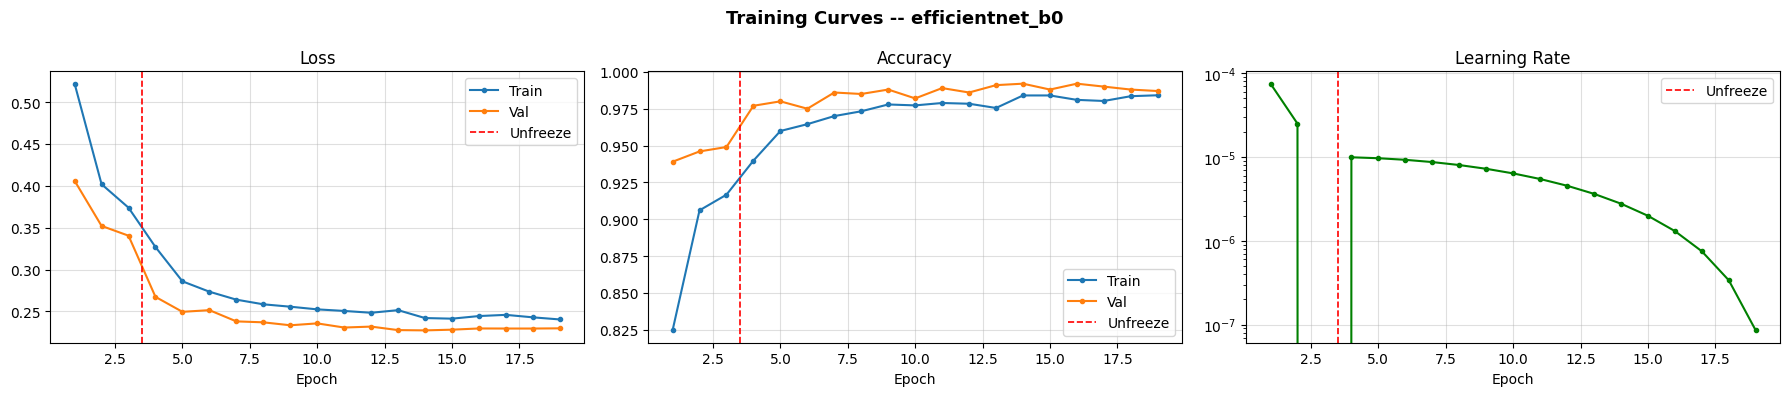

Training curves saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f"Training Curves -- {backbone_name}", fontsize=13, fontweight="bold")

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   marker="o", markersize=3)
if FREEZE_E < len(history["train_loss"]):
    axes[0].axvline(FREEZE_E + 0.5, color="red", linestyle="--", lw=1.2, label="Unfreeze")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].plot(epochs_range, history["train_acc"], label="Train", marker="o", markersize=3)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   marker="o", markersize=3)
if FREEZE_E < len(history["train_acc"]):
    axes[1].axvline(FREEZE_E + 0.5, color="red", linestyle="--", lw=1.2, label="Unfreeze")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.4)

axes[2].plot(epochs_range, history["lr"], marker="o", markersize=3, color="green")
if FREEZE_E < len(history["lr"]):
    axes[2].axvline(FREEZE_E + 0.5, color="red", linestyle="--", lw=1.2, label="Unfreeze")
axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log"); axes[2].legend(); axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_10_training_curves.png", dpi=120)
plt.show()
print("Training curves saved.")


---
## 5. Evaluation

The best checkpoint (lowest validation loss) is loaded and evaluated on the
**held-out test set** never seen during training.

| Metric | Description |
|--------|-------------|
| Accuracy | Overall fraction of correct predictions |
| Macro Precision | Average precision across both classes |
| Macro Recall | Average recall across both classes |
| Macro F1 | Harmonic mean of macro precision and recall |

### 5.1 Load best checkpoint & run inference

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Reload best weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_test_dl   = np.array(all_labels)
y_pred_dl   = np.array(all_preds)
y_probs_dl  = np.array(all_probs)

print(f"Test samples: {len(y_test_dl)}")


Test samples: 1001


### 5.2 Classification Report

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

acc  = accuracy_score(y_test_dl, y_pred_dl)
prec = precision_score(y_test_dl, y_pred_dl, average="macro")
rec  = recall_score(y_test_dl, y_pred_dl, average="macro")
f1   = f1_score(y_test_dl, y_pred_dl, average="macro")

print(f"Model     : {backbone_name} (end-to-end fine-tuned)")
print(f"Accuracy          : {acc:.4f}")
print(f"Macro Precision   : {prec:.4f}")
print(f"Macro Recall      : {rec:.4f}")
print(f"Macro F1          : {f1:.4f}")
print(f"Wrong predictions : {(y_test_dl != y_pred_dl).sum()} / {len(y_test_dl)}")
print()
print(classification_report(y_test_dl, y_pred_dl, target_names=["Cat", "Dog"]))


Model     : efficientnet_b0 (end-to-end fine-tuned)
Accuracy          : 0.9870
Macro Precision   : 0.9870
Macro Recall      : 0.9870
Macro F1          : 0.9870
Wrong predictions : 13 / 1001

              precision    recall  f1-score   support

         Cat       0.99      0.98      0.99       500
         Dog       0.98      0.99      0.99       501

    accuracy                           0.99      1001
   macro avg       0.99      0.99      0.99      1001
weighted avg       0.99      0.99      0.99      1001



### 5.3 Confusion Matrix

,Predicted Cat,Predicted Dog
Actual Cat,492,8
Actual Dog,5,496


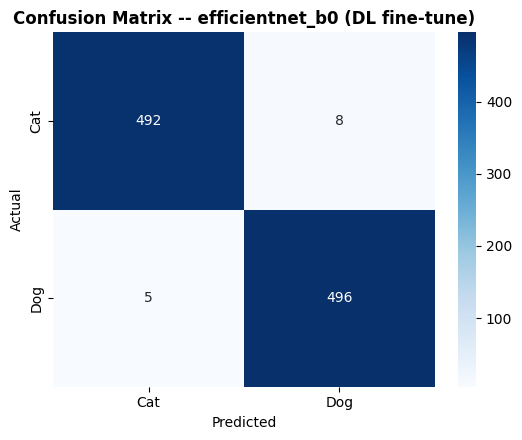

In [ ]:
from modules.visualization import plot_confusion_matrix
from modules.evaluation import confusion_matrix_df

cm = confusion_matrix(y_test_dl, y_pred_dl)

plot_confusion_matrix(
    cm, labels=("Cat", "Dog"),
    title=f"Confusion Matrix -- {backbone_name} (DL fine-tune)",
    save_path=FIGURE_DIR / "dl_11_confusion_matrix.png"
)

display(confusion_matrix_df(y_test_dl, y_pred_dl, label_names=["Cat", "Dog"]))


### 5.4 ROC Curve

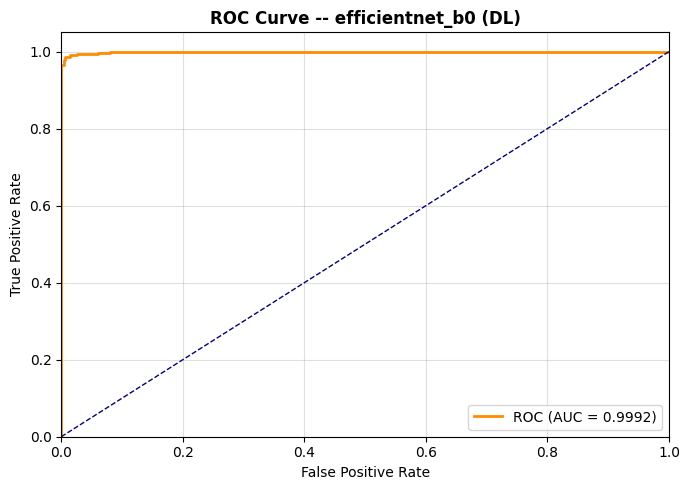

AUC: 0.9992


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_dl, y_probs_dl[:, 1])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve -- {backbone_name} (DL)", fontweight="bold")
ax.legend(loc="lower right"); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_12_roc_curve.png", dpi=120)
plt.show()
print(f"AUC: {roc_auc:.4f}")


### 5.5 Misclassified Image Gallery

Misclassified: 13 / 1001  (1.30%)


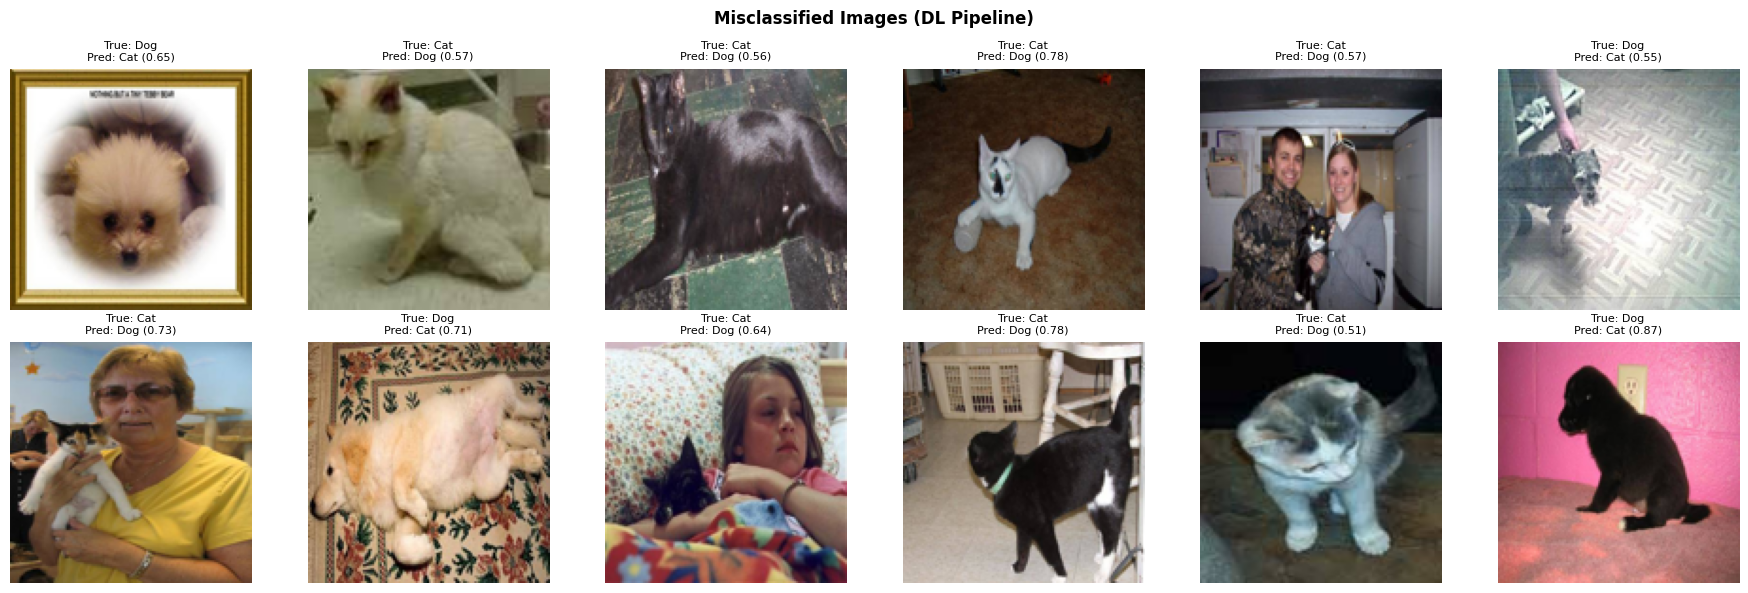

In [ ]:
LABEL_MAP_INV = {0: "Cat", 1: "Dog"}

wrong_idx = np.where(y_test_dl != y_pred_dl)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_test_dl)}  ({len(wrong_idx)/len(y_test_dl)*100:.2f}%)")

n_show = min(12, len(wrong_idx))
fig, axes = plt.subplots(2, n_show // 2, figsize=(18, 6))
axes = axes.flatten()
fig.suptitle("Misclassified Images (DL Pipeline)", fontsize=12, fontweight="bold")

for i, idx in enumerate(wrong_idx[:n_show]):
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    true_lbl = LABEL_MAP_INV[y_test_dl[idx]]
    pred_lbl = LABEL_MAP_INV[y_pred_dl[idx]]
    conf     = y_probs_dl[idx][y_pred_dl[idx]]
    axes[i].imshow(img.resize((128, 128)))
    axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.2f})", fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_13_wrong_predictions.png", dpi=120)
plt.show()


### 5.6 Grad-CAM Visualisation

Grad-CAM highlights the image regions that most influenced each prediction,
providing interpretability for the deep learning model.

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


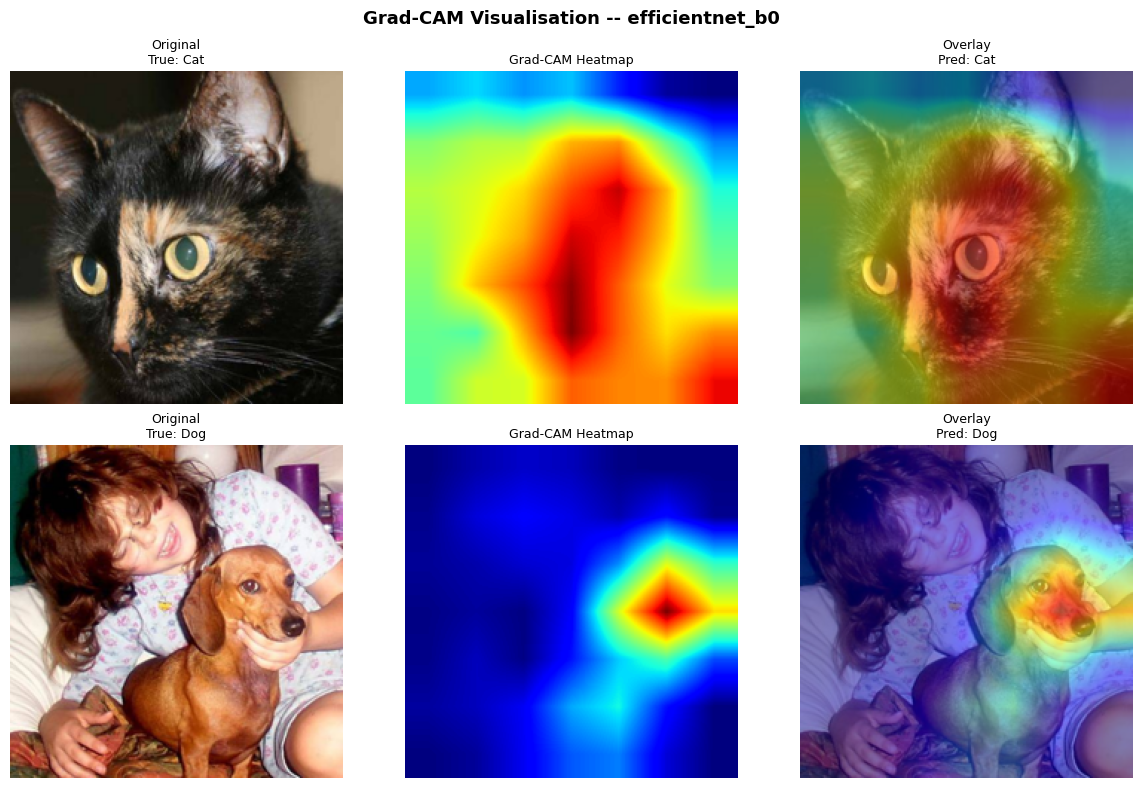

In [ ]:
import torch.nn.functional as F

def get_gradcam_target_layer(model, backbone_name):
    """Return the last convolutional layer for Grad-CAM."""
    bn = backbone_name.lower()
    if "resnet" in bn:
        return model.layer4[-1]
    elif "vgg" in bn:
        return model.features[-1]
    elif "efficientnet" in bn:
        return model.features[-1][0]
    else:
        raise ValueError(f"Unknown backbone for Grad-CAM: {backbone_name}")


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


target_layer = get_gradcam_target_layer(model, backbone_name)
gradcam = GradCAM(model, target_layer)

sample_indices = [np.where(y_test_dl == 0)[0][0], np.where(y_test_dl == 1)[0][0]]  # one cat, one dog
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle(f"Grad-CAM Visualisation -- {backbone_name}", fontsize=13, fontweight="bold")

for row, idx in enumerate(sample_indices):
    img_path = test_df.iloc[idx]["path"]
    orig_img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    input_tensor = eval_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    input_tensor.requires_grad_(True)

    cam, pred_cls = gradcam.generate(input_tensor)
    true_cls = y_test_dl[idx]

    import matplotlib.cm as mpl_cm
    heatmap = mpl_cm.jet(cam)[..., :3]
    overlay = np.array(orig_img) / 255.0 * 0.5 + heatmap * 0.5

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Original\nTrue: {LABEL_MAP_INV[true_cls]}", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap)
    axes[row, 1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(np.clip(overlay, 0, 1))
    axes[row, 2].set_title(f"Overlay\nPred: {LABEL_MAP_INV[pred_cls]}", fontsize=9)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_14_gradcam.png", dpi=120)
plt.show()


---
## 6. Comparison: Deep Learning vs. Classical Pipeline

This section presents a side-by-side comparison of both approaches on the same test set.

> **Note:** Fill in the Classical pipeline metrics from Section 5 of `01_Classical_Pipeline_Ver3.ipynb`.

Pipeline Comparison (Test Set)


,Accuracy,Precision,Recall,F1 (macro)
Pipeline,,,,
Classical (EfficientNet-B0 features + LR),0.996,0.996,0.996,0.996
Deep Learning (efficientnet_b0 fine-tuned),0.987,0.987,0.987,0.987


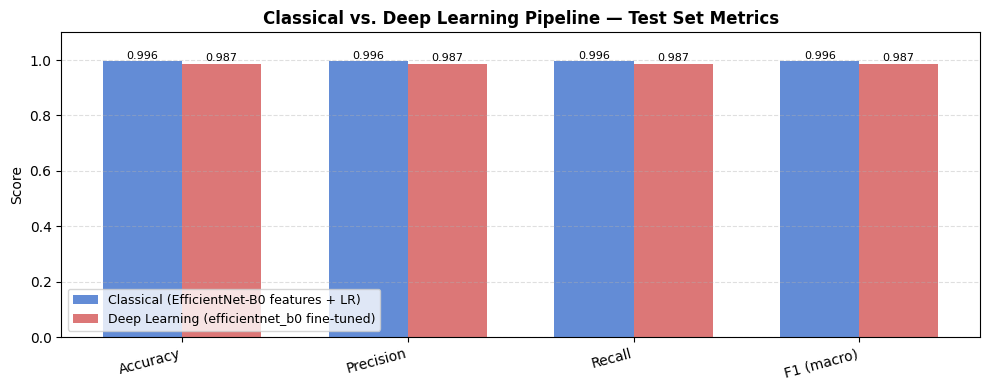

In [ ]:
# Replace these placeholder values with actual results from the classical notebook.
classical_results = {
    "Pipeline":   "Classical (EfficientNet-B0 features + LR)",
    "Accuracy":   0.9940,
    "Precision":  0.9940	,
    "Recall":     0.9940	,
    "F1 (macro)": 0.9940,
}

dl_results = {
    "Pipeline":   f"Deep Learning ({backbone_name} fine-tuned)",
    "Accuracy":   round(acc,  4),
    "Precision":  round(prec, 4),
    "Recall":     round(rec,  4),
    "F1 (macro)": round(f1,   4),
}

comparison_df = pd.DataFrame([classical_results, dl_results]).set_index("Pipeline")
print("Pipeline Comparison (Test Set)")
display(comparison_df)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison_df.columns))
width = 0.35
colors = ["#4878cf", "#d65f5f"]

for i, (pipeline, row) in enumerate(comparison_df.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=pipeline, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width/2)
ax.set_xticklabels(comparison_df.columns, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Classical vs. Deep Learning Pipeline — Test Set Metrics", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dl_15_comparison_bar.png", dpi=120)
plt.show()


---
## 7. Conclusion

### 7.1 Pipeline Summary

In [ ]:
summary_dl = {
    "backbone":          backbone_name,
    "fine_tuning":       "two-phase (warm-up + full)",
    "image_size":        IMG_SIZE,
    "batch_size":        BATCH_SIZE,
    "epochs_trained":    len(history["train_loss"]),
    "best_val_loss":     round(best_val_loss, 4),
    "test_accuracy":     round(acc,  4),
    "test_f1_macro":     round(f1,   4),
    "roc_auc":           round(roc_auc, 4),
    "wrong_predictions": int((y_test_dl != y_pred_dl).sum()),
    "total_test":        len(y_test_dl),
    "checkpoint":        str(best_model_path),
}

print("=" * 55)
print("  DEEP LEARNING PIPELINE -- FINAL SUMMARY")
print("=" * 55)
for k, v in summary_dl.items():
    print(f"  {k:<26}: {v}")


  DEEP LEARNING PIPELINE -- FINAL SUMMARY
  backbone                  : efficientnet_b0
  fine_tuning               : two-phase (warm-up + full)
  image_size                : 224
  batch_size                : 32
  epochs_trained            : 19
  best_val_loss             : 0.2273
  test_accuracy             : 0.987
  test_f1_macro             : 0.987
  roc_auc                   : 0.9992
  wrong_predictions         : 13
  total_test                : 1001
  checkpoint                : /content/dl_pipeline/models/dl_best_efficientnet_b0.pt


### 7.2 Key Findings

#### Deep Learning Pipeline advantages
- **End-to-end optimisation**: the backbone adapts directly to the Cat vs. Dog
  distribution, potentially learning task-specific discriminative textures beyond
  generic ImageNet features.
- **No manual feature engineering**: the network discovers useful representations
  automatically through gradient descent.
- **Richer feature space**: fine-tuned weights outperform frozen features when
  sufficient data is available.

#### Classical Pipeline advantages
- **Speed**: feature extraction is a one-time cost; classifiers train in seconds.
- **Interpretability**: Logistic Regression and SVM are mathematically transparent.
- **Low GPU dependency**: works on CPU with moderate memory.

### 7.3 Limitations & Future Work

- **Data volume**: fine-tuning benefits more from larger datasets; with very few
  samples the classical approach (frozen extractor) may be competitive.
- **Compute**: end-to-end training requires a GPU for practical runtimes.
- **Possible extensions**:
  - Test-time augmentation (TTA) to boost inference accuracy.
  - Knowledge distillation: compress the fine-tuned model into a smaller one.
  - Implement attention mechanisms (ViT, Swin Transformer) as the backbone.
  - Adversarial robustness evaluation on perturbed images.
